In [109]:
import pandas as pd
import numpy as np
import os
root_path = os.getcwd().replace('script', '')

## 0. Graph function

- ฟังก์ชันที่จำเป็นสำหับการพล็อตกราฟ เช่า Histogram, Bar plot, Box plot เป็นต้น

In [110]:
def plot_boxplots(df, cols=None, ncols=2, showfliers=True, notch=False, whis=1.5,
                  horizontal=False, order_by_median=False):
    """
    Plot box plots for numeric columns.

    Args:
        df (pd.DataFrame): your data
        cols (list[str] | None): which numeric columns to plot;
                                 if None, auto-detect numeric columns
        ncols (int): number of subplots per row
        showfliers (bool): show outlier points
        notch (bool): draw a notch to display the median CI
        whis (float | tuple): IQR whisker length or (lo, hi) percentiles (e.g., (5,95))
        horizontal (bool): if True, draw horizontal boxes
        order_by_median (bool): if True, sort columns by median before plotting
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Pick numeric columns if not provided
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not cols:
        raise ValueError("No numeric columns to plot.")

    # Optionally sort by column medians (ascending)
    if order_by_median:
        med = df[cols].median(numeric_only=True).sort_values()
        cols = med.index.tolist()

    nrows = -(-len(cols) // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4*nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        data = df[col].dropna()

        # seaborn handles nicer stats & fliers; orientation via x/y
        if horizontal:
            sns.boxplot(x=data, ax=ax, showfliers=showfliers, notch=notch, whis=whis)
            ax.set_xlabel(col)
            ax.set_ylabel("")
        else:
            sns.boxplot(y=data, ax=ax, showfliers=showfliers, notch=notch, whis=whis)
            ax.set_ylabel(col)
            ax.set_xlabel("")

        ax.set_title(f"{col} box plot")
        ax.grid(axis="y" if not horizontal else "x", linestyle="--", alpha=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Remove any unused axes
    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [111]:
def plot_numeric_distributions(
    df,
    cols=None,
    bins=30,
    ncols=2,
    kde=True,
    show_stats=True,          # <- new: show mean/var/std box
    ddof=1,                   # <- new: variance/SD degrees of freedom (1 = sample, 0 = population)
    stats_loc=(0.98, 0.98),   # <- new: box location in axes coords (x,y), 0..1
):
    """
    Plot histogram distributions for numeric columns, with robust column handling
    and per-plot statistics overlays (mean line, mean/variance/std box).

    Parameters
    ----------
    df : pandas.DataFrame
    cols : list[str] | None
        Which columns to plot; default = all numeric columns in df.
    bins : int
        Histogram bins.
    ncols : int
        Number of subplot columns.
    kde : bool
        Whether to draw a KDE curve (seaborn).
    show_stats : bool
        If True, annotate each chart with mean/variance/std and draw a mean line.
    ddof : int
        Delta degrees of freedom for var/std: 1 = sample, 0 = population.
    stats_loc : tuple[float, float]
        (x, y) in axes coordinates for the stats box (e.g., (0.02, 0.98) for top-left).
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from pandas.api.types import is_numeric_dtype
    from scipy import stats

    # 1) Decide candidate columns
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    else:
        cols = list(cols)

    # 2) Split into present vs. missing
    present = [c for c in cols if c in df.columns]
    missing = sorted(set(cols) - set(present))

    # 3) Keep only numeric among present
    non_numeric = [c for c in present if not is_numeric_dtype(df[c])]
    numeric_present = [c for c in present if is_numeric_dtype(df[c])]

    if missing:
        print(f"[plot_numeric_distributions] Skipped missing columns: {missing}")
    if non_numeric:
        print(f"[plot_numeric_distributions] Skipped non-numeric columns: {non_numeric}")

    if not numeric_present:
        raise ValueError("No valid numeric columns to plot after filtering.")

    # 5) Make grid
    ncols = max(1, int(ncols))
    n = len(numeric_present)
    nrows = -(-n // ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4*nrows))
    axes = np.atleast_1d(axes).ravel()

    # 6) Plot each numeric column
    for i, col in enumerate(numeric_present):
        ax = axes[i]
        data = df[col].dropna().astype(float)

        ax.hist(data, bins=bins, alpha=0.7, color='skyblue',
                edgecolor='black', density=True)

        if kde:
            kde_x = np.linspace(data.min(), data.max(), 200)
            kde_estimator = stats.gaussian_kde(data)
            ax.plot(kde_x, kde_estimator(kde_x), 'r-', linewidth=2, label='KDE')

            mu, sigma = data.mean(), data.std()
            normal_curve = stats.norm.pdf(kde_x, mu, sigma)
            ax.plot(kde_x, normal_curve, 'g--', linewidth=2,
                    label='Normal Distribution')

        # ===========================
        # ADD MEAN & MEDIAN LINES
        # ===========================
        mean = float(data.mean())
        median = float(data.median())

        ax.axvline(x=mean, color='red', linestyle='--',
                   linewidth=2, alpha=0.7, label="Mean")
        ax.axvline(x=median, color='orange', linestyle='--',
                   linewidth=2, alpha=0.7, label="Median")

        ax.set_title(f"{col} distribution", fontweight='bold')
        ax.set_xlabel(col, fontweight='bold')
        ax.set_ylabel("Density", fontweight='bold')
        ax.grid(alpha=0.3)
        ax.legend(loc='upper right')

        if show_stats and len(data):
            var = float(data.var(ddof=ddof))
            std = float(data.std(ddof=ddof))
            skewness = float(stats.skew(data))

            stats_text = (
                f"Mean:   {mean:.3f}\n"
                f"Median: {median:.3f}\n"
                f"Std:    {std:.3f}\n"
                f"Skew:   {skewness:.3f}"
            )

            ax.text(
                0.05, 0.95, stats_text,
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=9,
                bbox=dict(boxstyle='round',
                          facecolor='wheat', alpha=0.5)
            )

    for j in range(len(numeric_present), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [112]:
# categorical bar chart

def plot_bar_charts_grid(df, cols, top_n=None, normalize=False, ncols=3):
    """
    Grid of bar charts for categorical columns.

    Args:
        df (pd.DataFrame): your data
        cols (list[str]): columns to plot
        top_n (int|None): show only top N most frequent categories
        normalize (bool): if True, show percentages instead of raw counts
        ncols (int): number of charts per row
    """
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter

    def k_format(x, _):
        if x >= 1_000_000: return f"{int(x/1_000_000)}M"
        if x >= 1_000:     return f"{int(x/1_000)}k"
        return str(int(x))

    nrows = -(-len(cols) // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 3*nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        counts = (
            df[col]
            .astype("category")
            .cat.add_categories(["<NaN>"])
            .fillna("<NaN>")
            .value_counts(dropna=False)
            .sort_values(ascending=False)
        )
        if top_n:
            counts = counts.iloc[:top_n]

        vals = (counts / counts.sum() * 100.0).round(1) if normalize else counts

        vals.plot(kind="bar", ax=ax, color="skyblue", edgecolor="black")

        ax.set_title(f"{col} distribution")
        ax.set_xlabel("")
        ax.set_ylabel("Percent" if normalize else "Count")
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.tick_params(axis="x", labelrotation=30)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if not normalize:
            ax.yaxis.set_major_formatter(FuncFormatter(k_format))

        # annotate bars
        for rect, v in zip(ax.patches, vals.values):
            h = rect.get_height()
            label = f"{v:.1f}%" if normalize else f"{int(h)}"
            ax.annotate(label,
                        (rect.get_x() + rect.get_width()/2, h),
                        ha="center", va="bottom",
                        fontsize=0.5, xytext=(0, 3), textcoords="offset points")

    # remove unused subplots if cols not multiple of ncols
    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



# QA Analysis test lvl1

In [113]:
test = pd.read_csv(f'{root_path}\\tablev2\\QA_test.csv')

In [114]:
print(len(test))
test.head()

20


,Rainbow Group,Category,Question,Answer,Page
0,Construction-Related,Repair Method,เกณฑ์การซ่อมแซมรอยร้าว (Crack Repair) สำหรับรอ...,ต้องมีความกว้างของรอยร้าว (A) มากกว่า 0.1 มม. ...,3
1,Non-Construction Questions,General / Admin,ชื่อโครงการ (Project Name) ที่ระบุไว้ในเอกสารค...,SEWERAGE TUNNEL BUNG NONG BON TO CHAOPHRAYA RIVER,1
2,Construction-Related,Material,อัตราส่วนผสม (Mixing Ratio) ของวัสดุ Sikadur 5...,อัตราส่วนผสมคือ วัสดุ A : วัสดุ B = 2 : 1,17
3,Construction-Related,Environmental / Preventive Measures,มาตรการป้องกันผลกระทบด้านคุณภาพดินสำหรับวัสดุซ...,ให้ทำการเปลี่ยนบรรจุภัณฑ์หรือภาชนะที่สามารถปิด...,136
4,Construction-Related,Human Risk,อันตรายที่อาจเกิดขึ้นจากการใช้เครื่องเจียรคอนก...,ไฟฟ้าดูด และ โดนใบเจียรบาด,121


In [115]:
test['Question'][0]

'เกณฑ์การซ่อมแซมรอยร้าว (Crack Repair) สำหรับรอยร้าวแบบ Hard Crack ที่ต้องซ่อมแซมด้วย Cementitious Mortar คืออะไร'

In [116]:
result = pd.read_csv(f'{root_path}\\QA_test_out.csv')

In [117]:
result.columns

Index(['Rainbow Group', 'Category', 'Question', 'Answer', 'Page',
       'predicted_keyword_Rainbow Group', 'predicted_keyword_Category',
       'predicted_keyword_Answer', 'predicted_keyword_Page',
       'predicted_keyword_answer_model', 'predicted_keyword_raw_answer',
       'predicted_fulltext_Rainbow Group', 'predicted_fulltext_Category',
       'predicted_fulltext_Answer', 'predicted_fulltext_Page',
       'predicted_fulltext_answer_model', 'predicted_fulltext_raw_answer',
       'predicted_vector_Rainbow Group', 'predicted_vector_Category',
       'predicted_vector_Answer', 'predicted_vector_Page',
       'predicted_vector_answer_model', 'predicted_vector_raw_answer',
       'predicted_fused_Rainbow Group', 'predicted_fused_Category',
       'predicted_fused_Answer', 'predicted_fused_Page',
       'predicted_fused_answer_model', 'predicted_fused_raw_answer',
       'compute_time_s'],
      dtype='object')

In [118]:
result[['Rainbow Group', 
        'Category',
        'Answer', 
        'Page',]].head()

,Rainbow Group,Category,Answer,Page
0,Construction-Related,Repair Method,ต้องมีความกว้างของรอยร้าว (A) มากกว่า 0.1 มม. ...,3
1,Non-Construction Questions,General / Admin,SEWERAGE TUNNEL BUNG NONG BON TO CHAOPHRAYA RIVER,1
2,Construction-Related,Material,อัตราส่วนผสมคือ วัสดุ A : วัสดุ B = 2 : 1,17
3,Construction-Related,Environmental / Preventive Measures,ให้ทำการเปลี่ยนบรรจุภัณฑ์หรือภาชนะที่สามารถปิด...,136
4,Construction-Related,Human Risk,ไฟฟ้าดูด และ โดนใบเจียรบาด,121


In [119]:
print(result['predicted_fused_Answer'][0])

เกณฑ์การซ่อมแซมรอยร้าวแบบ Hard Crack ด้วย Cementitious Mortar มีดังนี้:
*   รอยร้าวมีความกว้าง (A) มากกว่า 0.1 มิลลิเมตร แต่น้อยกว่า 0.3 มิลลิเมตร
*   รอยร้าวมีความลึกมากกว่า 15 มิลลิเมตร


In [120]:
result[['predicted_keyword_Rainbow Group', 
        'predicted_keyword_Category',
        'Question',
        'predicted_keyword_Answer', 
        'predicted_keyword_Page',]].head()

,predicted_keyword_Rainbow Group,predicted_keyword_Category,Question,predicted_keyword_Answer,predicted_keyword_Page
0,Construction-Related,Repair Method,เกณฑ์การซ่อมแซมรอยร้าว (Crack Repair) สำหรับรอ...,เกณฑ์การซ่อมแซมรอยร้าวแบบ Hard Crack ด้วย Ceme...,"10, 52, 3, 47, 7"
1,Non-Construction Questions,General / Admin,ชื่อโครงการ (Project Name) ที่ระบุไว้ในเอกสารค...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"88, 83, 117, 107"
2,Construction-Related,Material,อัตราส่วนผสม (Mixing Ratio) ของวัสดุ Sikadur 5...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"60, 58, 47, 52, 61"
3,Construction-Related,Environmental / Preventive Measures,มาตรการป้องกันผลกระทบด้านคุณภาพดินสำหรับวัสดุซ...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"107, 117, 134, 135"
4,Construction-Related,Human Risk,อันตรายที่อาจเกิดขึ้นจากการใช้เครื่องเจียรคอนก...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"89, 88, 100, 84, 85"


In [121]:
result[['predicted_fulltext_Rainbow Group', 
        'predicted_fulltext_Category',
        'Question',
        'predicted_fulltext_Answer', 
        'predicted_fulltext_Page',]].head()

,predicted_fulltext_Rainbow Group,predicted_fulltext_Category,Question,predicted_fulltext_Answer,predicted_fulltext_Page
0,Construction-Related,Repair Method,เกณฑ์การซ่อมแซมรอยร้าว (Crack Repair) สำหรับรอ...,เกณฑ์การซ่อมแซมรอยร้าวแบบ Hard Crack ที่ต้องซ่...,"10, 52, 3, 47, 7"
1,Non-Construction Questions,General / Admin,ชื่อโครงการ (Project Name) ที่ระบุไว้ในเอกสารค...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"88, 83, 117, 107"
2,Construction-Related,Material,อัตราส่วนผสม (Mixing Ratio) ของวัสดุ Sikadur 5...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"60, 58, 47, 52, 61"
3,Construction-Related,Human Risk,มาตรการป้องกันผลกระทบด้านคุณภาพดินสำหรับวัสดุซ...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"107, 117, 134, 135"
4,Construction-Related,Human Risk,อันตรายที่อาจเกิดขึ้นจากการใช้เครื่องเจียรคอนก...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"89, 88, 100, 84, 85"


In [122]:
result[['predicted_vector_Rainbow Group', 
        'predicted_vector_Category',
        'Question',
        'predicted_vector_Answer', 
        'predicted_vector_Page',]].head()

,predicted_vector_Rainbow Group,predicted_vector_Category,Question,predicted_vector_Answer,predicted_vector_Page
0,Construction-Related,Repair Method,เกณฑ์การซ่อมแซมรอยร้าว (Crack Repair) สำหรับรอ...,เกณฑ์การซ่อมแซมรอยร้าวแบบ Hard Crack ที่ต้องซ่...,"7, 10, 115, 3, 52"
1,Construction-Related,Repair Method,ชื่อโครงการ (Project Name) ที่ระบุไว้ในเอกสารค...,SEWERAGE TUNNEL BUNG NONG BON TO CHAOPHRAYA RIVER,"97, 93, 64, 76, 32"
2,Construction-Related,Material,อัตราส่วนผสม (Mixing Ratio) ของวัสดุ Sikadur 5...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"60, 71, 47, 123, 13"
3,Construction-Related,Material,มาตรการป้องกันผลกระทบด้านคุณภาพดินสำหรับวัสดุซ...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"107, 117, 134, 113, 84"
4,Construction-Related,Human Risk,อันตรายที่อาจเกิดขึ้นจากการใช้เครื่องเจียรคอนก...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"100, 107, 46, 99, 83"


In [123]:
result[['Rainbow Group', 
        'Category',
        'Answer', 
        'Page',]].head()

,Rainbow Group,Category,Answer,Page
0,Construction-Related,Repair Method,ต้องมีความกว้างของรอยร้าว (A) มากกว่า 0.1 มม. ...,3
1,Non-Construction Questions,General / Admin,SEWERAGE TUNNEL BUNG NONG BON TO CHAOPHRAYA RIVER,1
2,Construction-Related,Material,อัตราส่วนผสมคือ วัสดุ A : วัสดุ B = 2 : 1,17
3,Construction-Related,Environmental / Preventive Measures,ให้ทำการเปลี่ยนบรรจุภัณฑ์หรือภาชนะที่สามารถปิด...,136
4,Construction-Related,Human Risk,ไฟฟ้าดูด และ โดนใบเจียรบาด,121


In [124]:
result[['predicted_fused_Rainbow Group', 
        'predicted_fused_Category',
        'Question',
        'predicted_fused_Answer', 
        'predicted_fused_Page',]].head()
        # 'predicted_fused_answer_model', 
        # 'predicted_fused_raw_answer']]

,predicted_fused_Rainbow Group,predicted_fused_Category,Question,predicted_fused_Answer,predicted_fused_Page
0,Construction-Related,Repair Method,เกณฑ์การซ่อมแซมรอยร้าว (Crack Repair) สำหรับรอ...,เกณฑ์การซ่อมแซมรอยร้าวแบบ Hard Crack ด้วย Ceme...,"10, 7, 52, 3, 47"
1,Construction-Related,Material,ชื่อโครงการ (Project Name) ที่ระบุไว้ในเอกสารค...,โครงการ (Project Name) ที่ระบุไว้ในเอกสารคือ:\...,"107, 88, 97, 83, 93"
2,Construction-Related,Material,อัตราส่วนผสม (Mixing Ratio) ของวัสดุ Sikadur 5...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"60, 47, 58, 71, 52"
3,Construction-Related,Human Risk,มาตรการป้องกันผลกระทบด้านคุณภาพดินสำหรับวัสดุซ...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"107, 117, 134, 84"
4,Construction-Related,Human Risk,อันตรายที่อาจเกิดขึ้นจากการใช้เครื่องเจียรคอนก...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"100, 89, 99, 88, 107"


In [125]:
result[['compute_time_s',
        'Rainbow Group', 
        'predicted_fused_Rainbow Group',
        'Category',
        'predicted_fused_Category',
        'Question',
        'Answer', 
        'predicted_fused_Answer', 
        'Page',
        'predicted_fused_Page']].head()

,compute_time_s,Rainbow Group,predicted_fused_Rainbow Group,Category,predicted_fused_Category,Question,Answer,predicted_fused_Answer,Page,predicted_fused_Page
0,34.55,Construction-Related,Construction-Related,Repair Method,Repair Method,เกณฑ์การซ่อมแซมรอยร้าว (Crack Repair) สำหรับรอ...,ต้องมีความกว้างของรอยร้าว (A) มากกว่า 0.1 มม. ...,เกณฑ์การซ่อมแซมรอยร้าวแบบ Hard Crack ด้วย Ceme...,3,"10, 7, 52, 3, 47"
1,35.81,Non-Construction Questions,Construction-Related,General / Admin,Material,ชื่อโครงการ (Project Name) ที่ระบุไว้ในเอกสารค...,SEWERAGE TUNNEL BUNG NONG BON TO CHAOPHRAYA RIVER,โครงการ (Project Name) ที่ระบุไว้ในเอกสารคือ:\...,1,"107, 88, 97, 83, 93"
2,33.38,Construction-Related,Construction-Related,Material,Material,อัตราส่วนผสม (Mixing Ratio) ของวัสดุ Sikadur 5...,อัตราส่วนผสมคือ วัสดุ A : วัสดุ B = 2 : 1,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,17,"60, 47, 58, 71, 52"
3,45.21,Construction-Related,Construction-Related,Environmental / Preventive Measures,Human Risk,มาตรการป้องกันผลกระทบด้านคุณภาพดินสำหรับวัสดุซ...,ให้ทำการเปลี่ยนบรรจุภัณฑ์หรือภาชนะที่สามารถปิด...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,136,"107, 117, 134, 84"
4,27.64,Construction-Related,Construction-Related,Human Risk,Human Risk,อันตรายที่อาจเกิดขึ้นจากการใช้เครื่องเจียรคอนก...,ไฟฟ้าดูด และ โดนใบเจียรบาด,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,121,"100, 89, 99, 88, 107"


In [126]:
result[['compute_time_s',
        'Rainbow Group', 
        'predicted_fused_Rainbow Group',
        'Category',
        'predicted_fused_Category',
        'Question',
        'Answer', 
        'predicted_fused_Answer', 
        'Page',
        'predicted_fused_Page']].to_csv(f'{root_path}\\tablev2\\QA_test_analysis.csv', index=False)

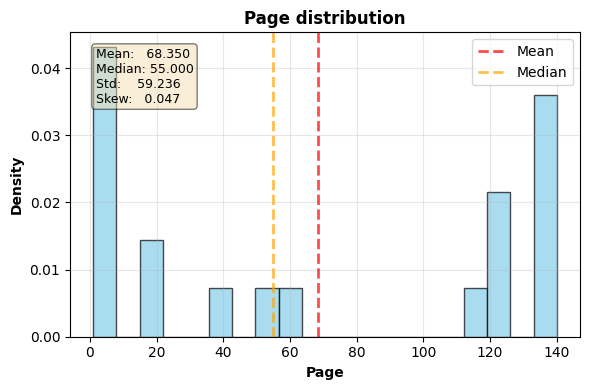

In [127]:
plot_numeric_distributions(test, cols=['Page'], bins=20, ncols=1, kde=False, show_stats=True)

# QA Analysis test lvl2

In [128]:
test = pd.read_csv(f'{root_path}\\tablev2\\QA_test_lvl2.csv')

In [129]:
print(len(test))
test.head()

20


,Rainbow Group,Category,Question,Answer,Page
0,Construction-Related,Repair Method / Material / Environmental,Question (TH) :ในการซ่อมแซมรูฟองอากาศ (Voids) ...,Answer (TH) :1. การเลือกวิธีซ่อม: รูฟองอากาศขน...,"6, 8, 135"
1,Construction-Related,Repair Method / Material / Human Risk,Question (TH) :หากช่างซ่อมบำรุงเผลอกลืนวัสดุ S...,Answer (TH) :1. ผลกระทบ: อาจเป็นอันตรายถึงตายไ...,130
2,Construction-Related,Repair Method / Material,Question (TH) :ในขั้นตอนการซ่อมแซมรอยแตกบิ่นที...,Answer (TH) :1. อัตราส่วนผสม (RP-TN-03): A:B =...,"26, 59"
3,Non-Construction Questions,Documentation / Quality Control,Question (TH) :หากต้องการบันทึกการซ่อมแซมชิ้นส...,Answer (TH) :1. แบบฟอร์ม: TUNNEL-QCY-RN-412. ผ...,141
4,Construction-Related,Repair Method / Material,Question (TH) :จากการตรวจสอบพบรอยร้าว (Hard Cr...,Answer (TH) :1. วิธีซ่อมแซม: RP-TN-02 (Repair ...,"3, 17"


In [130]:
test['Question'][0]

'Question (TH) :ในการซ่อมแซมรูฟองอากาศ (Voids) ที่มีขนาดความกว้าง 5 มม. และลึก 5 มม. โดยใช้วัสดุ Sika Skim Coat ผู้ปฏิบัติงานต้องปฏิบัติตามมาตรการป้องกันผลกระทบต่อสิ่งแวดล้อมด้านคุณภาพน้ำสำหรับวัสดุประเภทนี้อย่างไร'

In [131]:
result = pd.read_csv(f'{root_path}\\QA_test_lvl2_out.csv')

In [132]:
result.columns

Index(['Rainbow Group', 'Category', 'Question', 'Answer', 'Page',
       'predicted_keyword_Rainbow Group', 'predicted_keyword_Category',
       'predicted_keyword_Answer', 'predicted_keyword_Page',
       'predicted_keyword_answer_model', 'predicted_keyword_raw_answer',
       'predicted_fulltext_Rainbow Group', 'predicted_fulltext_Category',
       'predicted_fulltext_Answer', 'predicted_fulltext_Page',
       'predicted_fulltext_answer_model', 'predicted_fulltext_raw_answer',
       'predicted_vector_Rainbow Group', 'predicted_vector_Category',
       'predicted_vector_Answer', 'predicted_vector_Page',
       'predicted_vector_answer_model', 'predicted_vector_raw_answer',
       'predicted_fused_Rainbow Group', 'predicted_fused_Category',
       'predicted_fused_Answer', 'predicted_fused_Page',
       'predicted_fused_answer_model', 'predicted_fused_raw_answer',
       'compute_time_s'],
      dtype='object')

In [133]:
result[['Rainbow Group', 
        'Category',
        'Answer', 
        'Page',]].head()

,Rainbow Group,Category,Answer,Page
0,Construction-Related,Repair Method / Material / Environmental,Answer (TH) :1. การเลือกวิธีซ่อม: รูฟองอากาศขน...,"6, 8, 135"
1,Construction-Related,Repair Method / Material / Human Risk,Answer (TH) :1. ผลกระทบ: อาจเป็นอันตรายถึงตายไ...,130
2,Construction-Related,Repair Method / Material,Answer (TH) :1. อัตราส่วนผสม (RP-TN-03): A:B =...,"26, 59"
3,Non-Construction Questions,Documentation / Quality Control,Answer (TH) :1. แบบฟอร์ม: TUNNEL-QCY-RN-412. ผ...,141
4,Construction-Related,Repair Method / Material,Answer (TH) :1. วิธีซ่อมแซม: RP-TN-02 (Repair ...,"3, 17"


In [134]:
print(result['predicted_fused_Answer'][0])

ในการซ่อมแซมรูฟองอากาศด้วย Sika Skim Coat ซึ่งเป็นวัสดุซ่อมแบบผง ผู้ปฏิบัติงานต้องปฏิบัติตามมาตรการป้องกันผลกระทบต่อสิ่งแวดล้อมด้านคุณภาพน้ำดังนี้:

*   **มาตรการป้องกันผลกระทบกรณีวัสดุซ่อมแบบผงปนเปื้อนในท่อระบายน้ำเสีย:**
    1.  แบ่งพื้นที่สำหรับงานซ่อมแซม
    2.  ห้ามใช้วัสดุซ่อมนอกพื้นที่ที่จัดเตรียมไว้โดยเด็ดขาด
    3.  หากบรรจุภัณฑ์ฉีกขาด ให้เปลี่ยนบรรจุภัณฑ์ใหม่ หรือภาชนะที่สามารถปิดมิดชิดได้
    4.  ห้ามนำบรรจุภัณฑ์เก่ามาใช้โดยเด็ดขาด
*   **มาตรการป้องกันผลกระทบกรณีวัสดุซ่อมแบบผงปนเปื้อนในแหล่งน้ำธรรมชาติ:**
    1.  จัดพื้นที่สำหรับงานซ่อมแซมให้อยู่ห่างจากแหล่งน้ำธรรมชาติ เพื่อป้องกันการปนเปื้อน
    2.  จัดให้มีบ่อพักน้ำและบ่อบำบัดก่อนปล่อย


In [135]:
result[['predicted_keyword_Rainbow Group', 
        'predicted_keyword_Category',
        'Question',
        'predicted_keyword_Answer', 
        'predicted_keyword_Page',]].head()

,predicted_keyword_Rainbow Group,predicted_keyword_Category,Question,predicted_keyword_Answer,predicted_keyword_Page
0,Construction-Related,Human Risk,Question (TH) :ในการซ่อมแซมรูฟองอากาศ (Voids) ...,มาตรการป้องกันผลกระทบต่อสิ่งแวดล้อมด้านคุณภาพน...,"135, 100, 134, 10, 16"
1,Construction-Related,Human Risk,Question (TH) :หากช่างซ่อมบำรุงเผลอกลืนวัสดุ S...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"88, 117, 107, 89, 84"
2,Construction-Related,Material,Question (TH) :ในขั้นตอนการซ่อมแซมรอยแตกบิ่นที...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"4, 7, 47, 52, 24"
3,Construction-Related,Repair Method,Question (TH) :หากต้องการบันทึกการซ่อมแซมชิ้นส...,1. **แบบฟอร์มการบันทึกการซ่อมแซม:** TUNNEL-QC...,"141, 142, 140, 139, 57"
4,Construction-Related,Material,Question (TH) :จากการตรวจสอบพบรอยร้าว (Hard Cr...,1. สำหรับรอยร้าว (Hard Crack) ขนาดกว้าง 0.4 ม...,"3, 47, 52, 10, 16"


In [136]:
result[['predicted_fulltext_Rainbow Group', 
        'predicted_fulltext_Category',
        'Question',
        'predicted_fulltext_Answer', 
        'predicted_fulltext_Page',]].head()

,predicted_fulltext_Rainbow Group,predicted_fulltext_Category,Question,predicted_fulltext_Answer,predicted_fulltext_Page
0,Construction-Related,Environmental / Preventive Measures,Question (TH) :ในการซ่อมแซมรูฟองอากาศ (Voids) ...,ในการใช้ Sika Skim Coat ซึ่งจัดเป็นวัสดุซ่อมแซ...,"135, 100, 134, 10, 16"
1,Construction-Related,Human Risk,Question (TH) :หากช่างซ่อมบำรุงเผลอกลืนวัสดุ S...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"88, 117, 107, 89, 84"
2,Construction-Related,Material,Question (TH) :ในขั้นตอนการซ่อมแซมรอยแตกบิ่นที...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"4, 7, 47, 52, 24"
3,Construction-Related,Repair Method,Question (TH) :หากต้องการบันทึกการซ่อมแซมชิ้นส...,หากต้องการบันทึกการซ่อมแซมชิ้นส่วนอุโมงค์ประเภ...,"141, 142, 140, 139, 57"
4,Construction-Related,Material,Question (TH) :จากการตรวจสอบพบรอยร้าว (Hard Cr...,วิธีการซ่อมแซมสำหรับรอยร้าว (Hard Crack) ขนาดก...,"3, 47, 52, 10, 16"


In [137]:
result[['predicted_vector_Rainbow Group', 
        'predicted_vector_Category',
        'Question',
        'predicted_vector_Answer', 
        'predicted_vector_Page',]].head()

,predicted_vector_Rainbow Group,predicted_vector_Category,Question,predicted_vector_Answer,predicted_vector_Page
0,Construction-Related,Environmental / Preventive Measures,Question (TH) :ในการซ่อมแซมรูฟองอากาศ (Voids) ...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"45, 100, 134, 6, 72"
1,Construction-Related,Human Risk,Question (TH) :หากช่างซ่อมบำรุงเผลอกลืนวัสดุ S...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"91, 89, 85, 92"
2,Construction-Related,Material,Question (TH) :ในขั้นตอนการซ่อมแซมรอยแตกบิ่นที...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"7, 4, 24, 32, 60"
3,Construction-Related,Repair Method,Question (TH) :หากต้องการบันทึกการซ่อมแซมชิ้นส...,หากต้องการบันทึกการซ่อมแซมชิ้นส่วนอุโมงค์ประเภ...,"141, 142, 140, 139, 70"
4,Construction-Related,Material,Question (TH) :จากการตรวจสอบพบรอยร้าว (Hard Cr...,1. **วิธีการซ่อมแซมรหัส:**\n สำหรับรอยร้าว...,"3, 10, 16, 6, 70"


In [138]:
result[['Rainbow Group', 
        'Category',
        'Answer', 
        'Page',]].head()

,Rainbow Group,Category,Answer,Page
0,Construction-Related,Repair Method / Material / Environmental,Answer (TH) :1. การเลือกวิธีซ่อม: รูฟองอากาศขน...,"6, 8, 135"
1,Construction-Related,Repair Method / Material / Human Risk,Answer (TH) :1. ผลกระทบ: อาจเป็นอันตรายถึงตายไ...,130
2,Construction-Related,Repair Method / Material,Answer (TH) :1. อัตราส่วนผสม (RP-TN-03): A:B =...,"26, 59"
3,Non-Construction Questions,Documentation / Quality Control,Answer (TH) :1. แบบฟอร์ม: TUNNEL-QCY-RN-412. ผ...,141
4,Construction-Related,Repair Method / Material,Answer (TH) :1. วิธีซ่อมแซม: RP-TN-02 (Repair ...,"3, 17"


In [139]:
result[['predicted_fused_Rainbow Group', 
        'predicted_fused_Category',
        'Question',
        'predicted_fused_Answer', 
        'predicted_fused_Page',]].head()
        # 'predicted_fused_answer_model', 
        # 'predicted_fused_raw_answer']]

,predicted_fused_Rainbow Group,predicted_fused_Category,Question,predicted_fused_Answer,predicted_fused_Page
0,Construction-Related,Environmental / Preventive Measures,Question (TH) :ในการซ่อมแซมรูฟองอากาศ (Voids) ...,ในการซ่อมแซมรูฟองอากาศด้วย Sika Skim Coat ซึ่ง...,"100, 134, 45, 16, 135"
1,Construction-Related,Human Risk,Question (TH) :หากช่างซ่อมบำรุงเผลอกลืนวัสดุ S...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"89, 117, 91, 84, 92"
2,Construction-Related,Material,Question (TH) :ในขั้นตอนการซ่อมแซมรอยแตกบิ่นที...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"4, 7, 24, 29, 47"
3,Construction-Related,Repair Method,Question (TH) :หากต้องการบันทึกการซ่อมแซมชิ้นส...,หากต้องการบันทึกการซ่อมแซมชิ้นส่วนอุโมงค์ประเภ...,"141, 142, 140, 139, 146"
4,Construction-Related,Material,Question (TH) :จากการตรวจสอบพบรอยร้าว (Hard Cr...,สำหรับรอยร้าว (Hard Crack) ขนาดกว้าง 0.4 มม. ล...,"3, 10, 47, 16, 6"


In [140]:
result[['compute_time_s',
        'Rainbow Group', 
        'predicted_fused_Rainbow Group',
        'Category',
        'predicted_fused_Category',
        'Question',
        'Answer', 
        'predicted_fused_Answer', 
        'Page',
        'predicted_fused_Page']].head()

,compute_time_s,Rainbow Group,predicted_fused_Rainbow Group,Category,predicted_fused_Category,Question,Answer,predicted_fused_Answer,Page,predicted_fused_Page
0,73.26,Construction-Related,Construction-Related,Repair Method / Material / Environmental,Environmental / Preventive Measures,Question (TH) :ในการซ่อมแซมรูฟองอากาศ (Voids) ...,Answer (TH) :1. การเลือกวิธีซ่อม: รูฟองอากาศขน...,ในการซ่อมแซมรูฟองอากาศด้วย Sika Skim Coat ซึ่ง...,"6, 8, 135","100, 134, 45, 16, 135"
1,29.81,Construction-Related,Construction-Related,Repair Method / Material / Human Risk,Human Risk,Question (TH) :หากช่างซ่อมบำรุงเผลอกลืนวัสดุ S...,Answer (TH) :1. ผลกระทบ: อาจเป็นอันตรายถึงตายไ...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,130,"89, 117, 91, 84, 92"
2,37.23,Construction-Related,Construction-Related,Repair Method / Material,Material,Question (TH) :ในขั้นตอนการซ่อมแซมรอยแตกบิ่นที...,Answer (TH) :1. อัตราส่วนผสม (RP-TN-03): A:B =...,ไม่พบข้อมูลที่เกี่ยวข้องในเอกสาร / No relevant...,"26, 59","4, 7, 24, 29, 47"
3,28.63,Non-Construction Questions,Construction-Related,Documentation / Quality Control,Repair Method,Question (TH) :หากต้องการบันทึกการซ่อมแซมชิ้นส...,Answer (TH) :1. แบบฟอร์ม: TUNNEL-QCY-RN-412. ผ...,หากต้องการบันทึกการซ่อมแซมชิ้นส่วนอุโมงค์ประเภ...,141,"141, 142, 140, 139, 146"
4,43.38,Construction-Related,Construction-Related,Repair Method / Material,Material,Question (TH) :จากการตรวจสอบพบรอยร้าว (Hard Cr...,Answer (TH) :1. วิธีซ่อมแซม: RP-TN-02 (Repair ...,สำหรับรอยร้าว (Hard Crack) ขนาดกว้าง 0.4 มม. ล...,"3, 17","3, 10, 47, 16, 6"


In [141]:
result[['compute_time_s',
        'Rainbow Group', 
        'predicted_fused_Rainbow Group',
        'Category',
        'predicted_fused_Category',
        'Question',
        'Answer', 
        'predicted_fused_Answer', 
        'Page',
        'predicted_fused_Page']].to_csv(f'{root_path}\\tablev2\\QA_test_lvl2_analysis.csv', index=False)

In [142]:
# test['Page']

[' 6', ' 8', ' 135']
[' 130']
[' 26', ' 59']
[' 141']
[' 3', ' 17']
[' 13', ' 121']
[' 137', ' 138']
[' 4']
[' 11', ' 148']
[' 121']
[' 2']
[' 47', ' 51']
[' 6', ' 40']
[' 136']
[' 127']
[' 17', ' 19']
[' 4']
[' 122']
[' 8']
[' 120', ' 134']
[6, 8, 135, 130, 26, 59, 141, 3, 17, 13, 121, 137, 138, 4, 11, 148, 121, 2, 47, 51, 6, 40, 136, 127, 17, 19, 4, 122, 8, 120, 134]


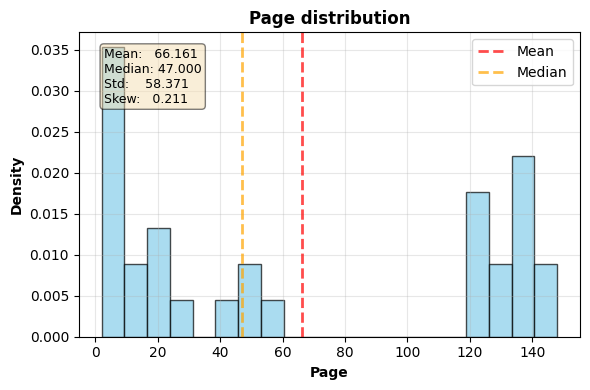

In [143]:
page_list = []
for i in range(len(test)):
    page_extract = test['Page'][i].split(',')
    print(page_extract)
    for page in page_extract:
        page_list.append(int(page.strip()))
page_extract_df = pd.DataFrame(page_list, columns=['Page'])
print(page_list)
plot_numeric_distributions(page_extract_df, cols=['Page'], bins=20, ncols=1, kde=False, show_stats=True)